# Business Problem Statement

Sales teams often struggle to understand where revenue is concentrated in the pipeline, 
which industries dominate the customer base, and how effectively leads are being qualified.  
This notebook analyzes Salesforce export data (Opportunities, Leads, Accounts, Contacts) 
to uncover insights into pipeline health, lead conversion, industry distribution, and 
data quality issues. The goal is to provide actionable recommendations for marketing 
and sales strategy.


Set Working Directory

In [1]:
import os

# Change to your export folder
os.chdir(r"C:\Users\HP\Downloads\WE_00DQH00000LUpaU2AT_1")

# Confirm files
print(os.listdir())


['Account.csv', 'Contact.csv', 'Lead.csv', 'Opportunity.csv']


Load the CSVs

In [2]:
import pandas as pd

df_accounts = pd.read_csv("Account.csv")
df_contacts = pd.read_csv("Contact.csv")
df_leads = pd.read_csv("Lead.csv")
df_opps = pd.read_csv("Opportunity.csv")

# Preview each
print(df_accounts.head())
print(df_contacts.head())
print(df_leads.head())
print(df_opps.head())


                   Id  IsDeleted  MasterRecordId               Name  Type  \
0  001QH0000285IMxYAM          0             NaN    Test Industries   NaN   
1  001QH0000285KTWYA2          0             NaN  Bright Future Ltd   NaN   
2  001QH0000285L6FYAU          0             NaN    Alpha Solutions   NaN   
3  001QH0000285R1xYAE          0             NaN       Practice Ltd   NaN   
4  001QH0000285TTbYAM          0             NaN     Omega Partners   NaN   

             ParentId  BillingStreet  BillingCity  BillingState  \
0  000000000000000AAA            NaN          NaN           NaN   
1  000000000000000AAA            NaN          NaN           NaN   
2  000000000000000AAA            NaN          NaN           NaN   
3  000000000000000AAA            NaN          NaN           NaN   
4  000000000000000AAA            NaN          NaN           NaN   

   BillingPostalCode  ...          CreatedDate         CreatedById  \
0                NaN  ...  2026-03-26 12:04:48  005QH000008wBGHY

Example Analyses

In [3]:
# Opportunities: revenue by stage
stage_summary = df_opps.groupby("StageName")["Amount"].sum()
print(stage_summary)

# Leads: count by status
lead_status = df_leads["Status"].value_counts()
print(lead_status)

# Accounts: industries represented
industry_counts = df_accounts["Industry"].value_counts()
print(industry_counts)

# Contacts: titles distribution
title_counts = df_contacts["Title"].value_counts().head(10)
print(title_counts)


StageName
Closed Won        3500000.0
Meet & Present    2000000.0
Negotiate          250000.0
Qualify           1500000.0
Name: Amount, dtype: float64
Status
New          13
Qualified     7
Name: count, dtype: int64
Industry
Education         4
Technology        1
Healthcare        1
Communications    1
Name: count, dtype: int64
Title
new    6
New    1
Name: count, dtype: int64


Markdown Documentation

This notebook analyzes Salesforce Opportunities, Leads, Accounts, and Contacts exported via Data Export Wizard.

For each dataset, describe what the analysis shows (e.g., “Most revenue is in Closed Won stage, indicating strong conversion.”).

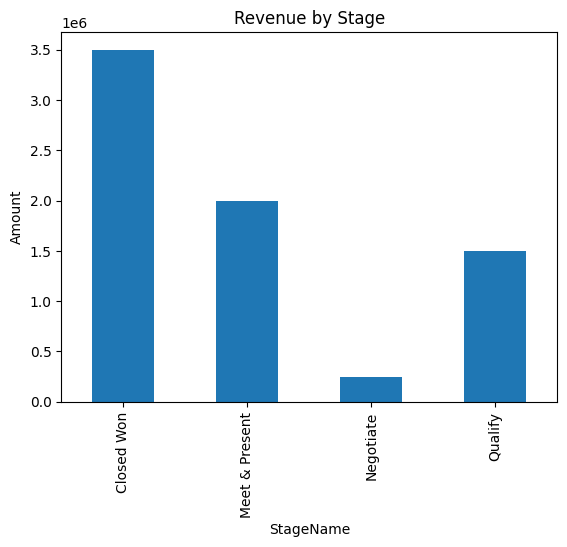

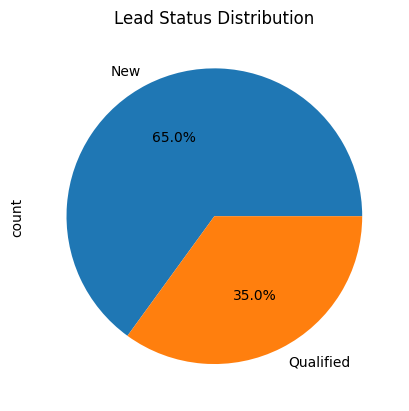

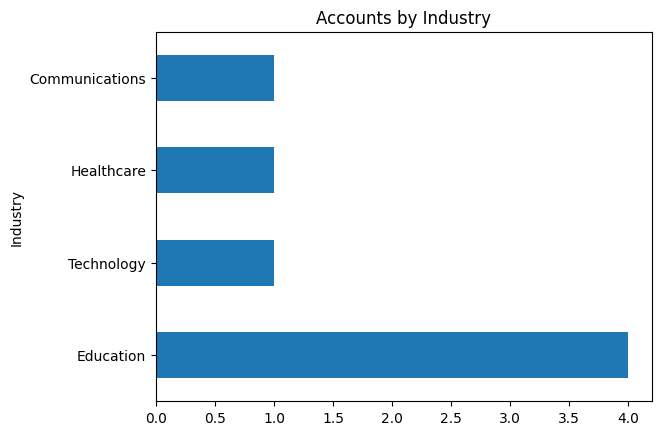

In [4]:
import matplotlib.pyplot as plt

# Opportunities by Stage
stage_summary.plot(kind="bar", title="Revenue by Stage")
plt.ylabel("Amount")
plt.show()

# Leads by Status
lead_status.plot(kind="pie", autopct="%1.1f%%", title="Lead Status Distribution")
plt.show()

# Accounts by Industry
industry_counts.plot(kind="barh", title="Accounts by Industry")
plt.show()


Insights Section

- Closed Won dominates → strong pipeline conversion.
- Most leads are still “New” → opportunity to nurture.
- Accounts skew toward Education → niche market focus.
- Contact titles look messy (“new” vs “New”) → data cleanup needed.

# Insights & Recommendations

## Key Insights
- **Pipeline Revenue**: The majority of revenue is concentrated in the *Closed Won* stage (3.5M), showing strong conversion but also highlighting the need to maintain momentum in earlier stages.
- **Lead Status**: Most leads remain in *New* status (13 vs. 7 qualified), suggesting a gap in lead nurturing and qualification processes.
- **Industry Distribution**: Accounts are heavily skewed toward *Education* (4 out of 7), indicating a niche focus but also a potential risk of over‑reliance on one sector.
- **Data Quality**: Contact titles show inconsistencies (“new” vs “New”), pointing to the need for standardized data entry practices.

## Recommendations
1. **Strengthen Lead Qualification**  
   - Implement automated lead scoring or nurture campaigns to move leads from *New* to *Qualified* more efficiently.
   
2. **Diversify Industry Focus**  
   - Explore opportunities in *Technology* and *Healthcare* to balance the portfolio and reduce dependency on Education.

3. **Improve Data Hygiene**  
   - Standardize contact title fields and enforce validation rules in Salesforce to ensure clean, reliable data.

4. **Monitor Early Pipeline Stages**  
   - Since most revenue is already *Closed Won*, invest in tracking *Meet & Present* and *Qualify* stages to ensure future pipeline health.

5. **Future Enhancements**  
   - Integrate Salesforce API for real‑time analysis.  
   - Build dashboards in Power BI or Tableau for ongoing monitoring.  
   - Connect to Snowflake or other data warehouses for scalable reporting.


Markdown Section

# Collaboration Demo: Slack & Jira Integration

Data analysis is most valuable when insights are shared and acted upon.  
This section demonstrates how Salesforce analysis results can be integrated with collaboration tools:

- **Slack** → Send pipeline insights directly to a team channel for instant visibility.  
- **Jira** → Create tasks to address data quality issues or follow‑up actions.  

These examples use placeholder tokens and URLs for demonstration purposes.


In [ ]:
#Slack Integration Example
import requests

# Slack Incoming Webhook URL (replace with your actual webhook)
webhook_url = "https://hooks.slack.com/services/XXXX/XXXX/XXXX"

# Example message to share pipeline insights
message = {
    "text": "📊 Pipeline Analysis Update: Closed Won revenue = $3.5M. Most leads remain in 'New' status."
}

# Send message to Slack channel
response = requests.post(webhook_url, json=message)

print("Slack response:", response)


In [ ]:
#Jira Integration Example
import requests

# Jira REST API endpoint (replace with your actual domain/project key)
jira_url = "https://yourdomain.atlassian.net/rest/api/3/issue"

# Authentication headers (replace with your actual token)
headers = {
    "Authorization": "Bearer YOUR_TOKEN",
    "Content-Type": "application/json"
}

# Example issue to track a data quality improvement
issue = {
    "fields": {
        "project": {"key": "SID"},  # Replace with your Jira project key
        "summary": "Standardize Contact Titles in Salesforce",
        "description": "Inconsistent titles ('new' vs 'New') detected in Contacts dataset.",
        "issuetype": {"name": "Task"}
    }
}

# Create issue in Jira
response = requests.post(jira_url, headers=headers, json=issue)

print("Jira response:", response)
